<div style='color: #216969;
           background-color: #EAF6F6;
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
SVM  ....
<a class="anchor" id="1"></a> 

In [2]:

# dataset laading 
import pandas as pd
df= pd.read_csv("../data/HousePrice3.csv",  index_col=0)

In [3]:
df.head() # display the first 5 rows

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Display a random  row  of the dataset
num_features=df.select_dtypes("number")
num_features.sample()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
269,270,20,NaN,7917,6,7,1976,1976,174.0,751,...,370,30,0,0,0,0,0,5,2007,148000


In [5]:
# display correlation  rate values to the target variable SalePrice
cormat=num_features.corr()["SalePrice"].sort_values(ascending=False)
cormat.nlargest(9)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageArea      0.623431
TotalBsmtSF     0.613581
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

In [6]:
#  Missing values  sorted by the number of descending    values

df[num_features.columns].isna().sum().sort_values(ascending=False)


LotFrontage      259
MasVnrArea         8
Id                 0
MSSubClass         0
LotArea            0
OverallCond        0
OverallQual        0
YearBuilt          0
YearRemodAdd       0
BsmtFinSF1         0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
dtype: int64

In [7]:
#   simple imputation of missing values
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="mean")
df[num_features.columns]= imputer.fit_transform(df[num_features.columns])

In [8]:
df.isna().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 78, dtype: int64

In [9]:
# use bestselec regression to select most important features 
from sklearn.linear_model import LassoCV


In [10]:
# display only features from 1 to last feature, excluding the target variable
df.iloc[:, 1:-1].head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60.0,RL,65.0,8450.0,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0.0,0.0,NaN,NaN,NaN,0.0,2.0,2008.0,WD,Normal
1,20.0,RL,80.0,9600.0,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0.0,0.0,NaN,NaN,NaN,0.0,5.0,2007.0,WD,Normal
2,60.0,RL,68.0,11250.0,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0.0,0.0,NaN,NaN,NaN,0.0,9.0,2008.0,WD,Normal
3,70.0,RL,60.0,9550.0,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0.0,0.0,NaN,NaN,NaN,0.0,2.0,2006.0,WD,Abnorml
4,60.0,RL,84.0,14260.0,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0.0,0.0,NaN,NaN,NaN,0.0,12.0,2008.0,WD,Normal


In [11]:
# df[["OverallQual", "TotalSF"  , "GarageCars", "GarageArea", "TotalBath", "1stFlrSF"]].corr().T
df.iloc[:, 1:-1].describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753
std,42.300571,22.024023,9981.264932,1.382997,1.112799,30.202904,20.645407,180.569112,456.098091,161.319273,...,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000
50%,50.000000,70.049958,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,70.000000,79.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,0.000000,...,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000


In [12]:
# display the correlation matrix of the  target variable SalePrice
df.iloc[:, 1:].select_dtypes("number").corr()["SalePrice"].sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageArea      0.623431
TotalBsmtSF     0.613581
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.475241
Name: SalePrice, dtype: float64

$\Large z= \frac{x- \mu}{\sigma}$

$\large \mu : Mean$

$\large \sigma:  Standard Deviation $

In [13]:
# normalize the datatarget set
from sklearn.preprocessing import MinMaxScaler  
scaler = MinMaxScaler()

df["Scaled_SalePrice"]=scaler.fit_transform(df[["SalePrice"]])

![](https://i.ibb.co/HKBwYww/svm-7.png)

![](../../imgs/target.jpeg)

In [14]:
df.iloc[:, 1:-2].select_dtypes("number").columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageArea',
       'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold'],
      dtype='object')

In [15]:
X=df.iloc[:, 1:-2].select_dtypes("number")
y=df["Scaled_SalePrice"]


![](../../imgs/datSplit.jpg)

In [16]:
# split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y  ,test_size=.3, random_state=42)

![](../../imgs/model.png)

In [17]:
# SVR model 
from sklearn.svm import SVR
SVReg=SVR( kernel="rbf" , C=.5, epsilon=.01)

In [18]:

# fit the model
SVReg.fit(X_train, y_train)

SVR(C=0.5, epsilon=0.01)

In [19]:
# Prediction
y_train_pred= SVReg.predict(X_train)
y_test_pred= SVReg.predict(X_test)

![](../../imgs/metrics.png)

In [20]:
print(f" Score  : {SVReg.score(X_test, y_test):.3f}")

 Score  : 0.764


In [21]:
# metric evaluation
# MAE, MSE, RMSE
from sklearn import metrics
import numpy as np
print(f" MAE  : {metrics.mean_absolute_error(y_test, y_test_pred):.3f}")
print(f" MSE  : {metrics.mean_squared_error(y_test, y_test_pred):.3f}")
print(f" RMSE : {np.sqrt(metrics.r2_score(y_test, y_test_pred)):.3f}")

 MAE  : 0.036
 MSE  : 0.003
 RMSE : 0.874


In [22]:
f" Coefficients : {SVReg.epsilon}"

' Coefficients : 0.01'

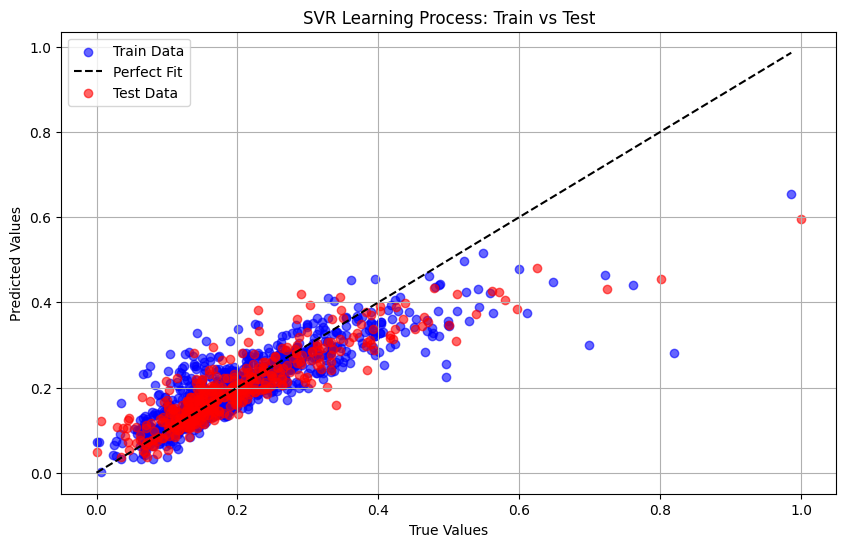

In [23]:
# Plot the learning process
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

# Training data plot
plt.scatter(y_train, y_train_pred, color="blue", label="Train Data", alpha=0.6)
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color="black", linestyle="--", label="Perfect Fit")

# Testing data plot
plt.scatter(y_test, y_test_pred, color="red", label="Test Data", alpha=0.6)

# Add labels, legend, and title
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("SVR Learning Process: Train vs Test")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

$$\Large \text{y_pred} = -3.706 + 0.308\color{red}*{OverallQual} + 0.516 *10^{-3}\color{red}*{TotalSF} + 0.287\color{red}*{GarageCars}  $$

In [24]:
df_pred =pd.DataFrame( {"Actual_P": y_test, "Predicted_P": y_test_pred })
df_pred

,Actual_P,Predicted_P
892,0.166088,0.143415
1105,0.402861,0.392147
413,0.111235,0.121984
522,0.172337,0.182816
1036,0.389668,0.302431
...,...,...
331,0.144563,0.145075
323,0.126753,0.145136
650,0.237536,0.197519
439,0.104291,0.139646


In [25]:
# pd.DataFrame({
# "Original_Price": scaler.inverse_transform(df_pred.Actual_P),
# "Predicted_Price":scaler.inverse_transform(df_pred.Predicted_P),
#  }).head()

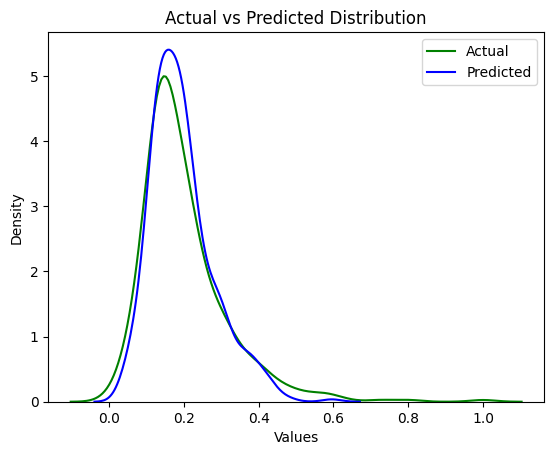

In [26]:
#   تخطيط البيانات الاصلية  / التنبؤ
import seaborn as sns
import matplotlib.pyplot as plt


# Plot the actual and predicted values
sns.kdeplot(df_pred.Actual_P, label="Actual", color="g", fill=False)
sns.kdeplot(df_pred.Predicted_P, label="Predicted", color="b", fill=False)

# Add labels and legend
plt.xlabel("Values")
plt.ylabel("Density")
plt.title("Actual vs Predicted Distribution")
plt.legend()

# Show the plot
plt.show()

In [27]:
df_pred.keys()

Index(['Actual_P', 'Predicted_P'], dtype='object')

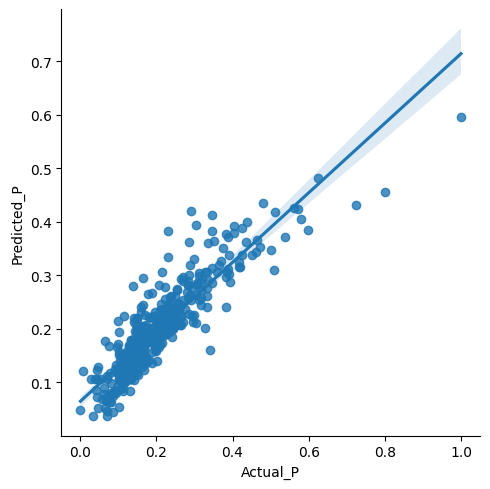

In [28]:
import seaborn as sns
# sns.set()
_=sns.lmplot(x="Actual_P",  y="Predicted_P", data=df_pred)

In [29]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


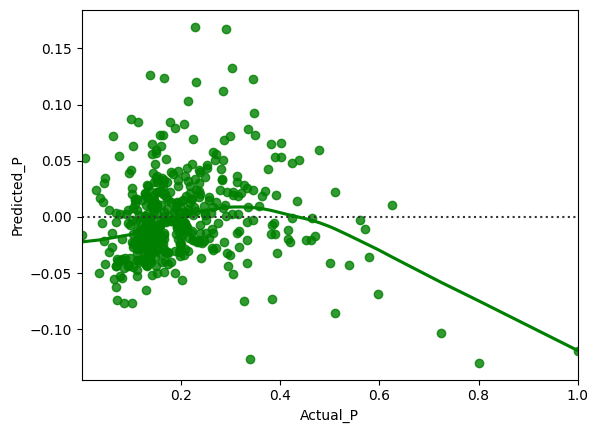

In [30]:
import seaborn as sns

# Residual plot
_=sns.residplot(x=df_pred.Actual_P, y=df_pred.Predicted_P, lowess=True, color="g")

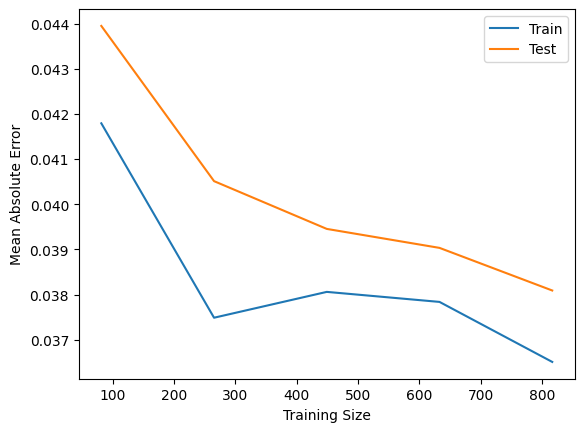

In [33]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(SVReg, X_train, y_train, scoring="neg_mean_absolute_error")
plt.plot(train_sizes, -train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, -test_scores.mean(axis=1), label="Test")
plt.xlabel("Training Size")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.show()

In [34]:
np.geomspace(0.01, 1, 10, endpoint=True)

array([0.01      , 0.01668101, 0.02782559, 0.04641589, 0.07742637,
       0.12915497, 0.21544347, 0.35938137, 0.59948425, 1.        ])

In [35]:
from sklearn.model_selection import validation_curve
from sklearn.linear_model import Ridge
import numpy as np

C_param=np.geomspace(0.01, 1, 10)
from sklearn.model_selection import validation_curve
train_scores, test_scores = validation_curve(estimator=SVReg,
                                              X=X_train,
                                              y=y_train,
                                              param_name="C" ,
                                              param_range=C_param,
                                              cv=10
 )

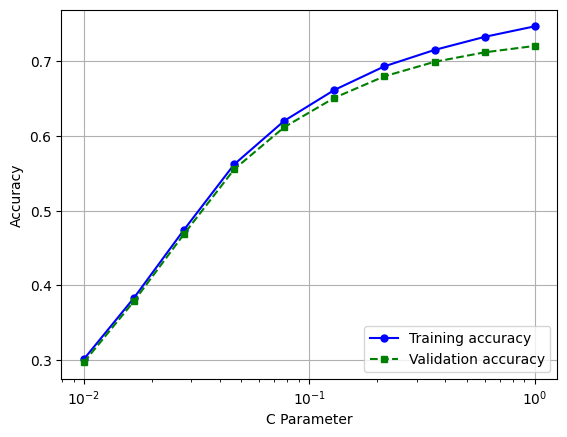

In [36]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
plt.plot(C_param, train_mean, color='blue', marker='o',markersize=5, label='Training accuracy')
plt.plot(C_param, test_mean,color='green', linestyle='--',marker='s', markersize=5,label='Validation accuracy')
plt.grid()
plt.xscale('log')

plt.xlabel('C Parameter')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.xlim()
plt.show()

In [37]:
from sklearn.model_selection import validation_curve
from sklearn.linear_model import Ridge
import numpy as np

Ep_param=np.geomspace(0.01, 1, 10)
from sklearn.model_selection import validation_curve
train_scores, test_scores = validation_curve(estimator=SVReg,
                                              X=X_train,
                                              y=y_train,
                                              param_name="epsilon" ,
                                              param_range=Ep_param,
                                              cv=10
 )

- Parameter ε controls the width of the ε-insensitive zone, used to fit the training data. The value of ε can affect the number of support vectors used to construct the regression function. The bigger ε, the fewer support vectors are selected. On the other hand, bigger ε-values results in more flat estimates.

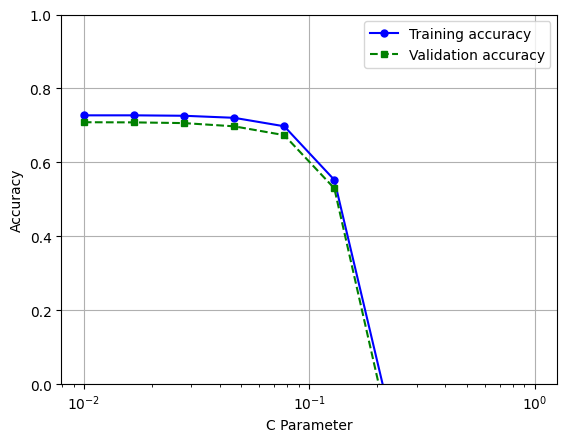

In [38]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
plt.plot(Ep_param, train_mean, color='blue', marker='o',markersize=5, label='Training accuracy')
plt.plot(Ep_param, test_mean,color='green', linestyle='--',marker='s', markersize=5,label='Validation accuracy')
plt.grid()
plt.xscale('log')

plt.xlabel('C Parameter')
plt.ylabel('Accuracy')
plt.legend(loc='upper right')
plt.ylim(0,1)

plt.show()

In [ ]:
pwd

'/content'

bash: line 1: syntax error near unexpected token `do'
bash: line 1: `$ for f in * ; do'
